In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os


In [ ]:
# Replace with your actual file path in Drive
data_path = '/content/drive/MyDrive/Project/Datasets/CICIDS2017_Merged.csv'
df = pd.read_csv(data_path, low_memory=False)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,SourceFile
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


In [ ]:
# Drop columns that don't help in classification
drop_cols = ['Flow ID', 'Timestamp', 'Source IP', 'Destination IP',
             'Source Port', 'Destination Port', 'Protocol']

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Drop fully null columns
df.dropna(axis=1, how='all', inplace=True)

# Drop constant columns
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index
df.drop(columns=constant_cols, inplace=True)

print("After column cleanup:", df.shape)


After column cleanup: (2830743, 72)


In [ ]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaNs in numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Drop rows still containing NaNs in key features
df.dropna(thresh=int(0.8 * df.shape[1]), inplace=True)

print("After missing value handling:", df.shape)

After missing value handling: (2830743, 72)


In [ ]:
print("Columns in the DataFrame:")
print(df.columns.tolist())


Columns in the DataFrame:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count', ' 

In [ ]:
# Strip spaces from all column names
df.columns = df.columns.str.strip()

# Clean the 'Label' column
df['Label'] = df['Label'].astype(str).str.strip().str.replace('�', '-', regex=False)

# Print unique labels to verify what we have
print("Unique values in cleaned 'Label' column:")
print(sorted(df['Label'].unique()))


Unique values in cleaned 'Label' column:
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [ ]:
# Define custom mapping
label_mapping = {
    'BENIGN': 'BENIGN',
    'Bot': 'Bot',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS-Hulk',
    'DoS GoldenEye': 'DoS-GoldenEye',
    'DoS slowloris': 'DoS-slowloris',
    'DoS Slowhttptest': 'DoS-slowhttptest',
    'FTP-Patator': 'FTP-Patator',
    'SSH-Patator': 'SSH-Patator',
    'PortScan': 'PortScan',
    'Web Attack - Brute Force': 'Web-BruteForce',
    'Web Attack - XSS': 'Web-XSS',
    'Web Attack - Sql Injection': 'Web-SQLi',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Apply mapping
df['Label'] = df['Label'].map(label_mapping)

# Confirm results
print("Final mapped classes:", sorted(df['Label'].unique()))


Final mapped classes: ['BENIGN', 'Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-slowhttptest', 'DoS-slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web-BruteForce', 'Web-SQLi', 'Web-XSS']


In [ ]:
# Make a copy to avoid side effects
df_clean = df.copy()

# Manual label mapping
df_clean.loc[df_clean['Label'] == 'BENIGN', 'Label'] = 0  # Normal

# DoS attacks → 1
df_clean.loc[df_clean['Label'] == 'DoS-GoldenEye', 'Label'] = 1
df_clean.loc[df_clean['Label'] == 'DoS-slowloris', 'Label'] = 1
df_clean.loc[df_clean['Label'] == 'DoS-slowhttptest', 'Label'] = 1
df_clean.loc[df_clean['Label'] == 'DoS-Hulk', 'Label'] = 1

# PortScan → 2
df_clean.loc[df_clean['Label'] == 'PortScan', 'Label'] = 2

# DDoS → 3
df_clean.loc[df_clean['Label'] == 'DDoS', 'Label'] = 3

# Brute Force (FTP + SSH) → 4
df_clean.loc[df_clean['Label'] == 'FTP-Patator', 'Label'] = 4
df_clean.loc[df_clean['Label'] == 'SSH-Patator', 'Label'] = 4

# Bot → 5
df_clean.loc[df_clean['Label'] == 'Bot', 'Label'] = 5

# Web attacks, Infiltration, Heartbleed → 6
df_clean.loc[df_clean['Label'].isin([
    'Web-BruteForce', 'Web-XSS', 'Web-SQLi', 'Infiltration', 'Heartbleed'
]), 'Label'] = 6

# Convert final label column to integer
df_clean['Label'] = df_clean['Label'].astype(int)

# Verify distribution
print("Final class distribution:")
print(df_clean['Label'].value_counts().sort_index())


Final class distribution:
Label
0    2273097
1     252661
2     158930
3     128027
4      13835
5       1966
6       2227
Name: count, dtype: int64


In [ ]:
df_clean.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,SourceFile
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,Monday-WorkingHours.pcap_ISCX.csv


In [ ]:
# Group by 'Label' and get top 5 rows from each group
top5_per_class = df_clean.groupby('Label').head(5)

# Display the result
top5_per_class


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,SourceFile
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,0,Monday-WorkingHours.pcap_ISCX.csv
541265,80,5216127,3,1,0,0,0,0,0.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,4,Tuesday-WorkingHours.pcap_ISCX.csv
541266,21,20,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,4,Tuesday-WorkingHours.pcap_ISCX.csv
541267,21,38,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,4,Tuesday-WorkingHours.pcap_ISCX.csv
541268,21,80,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,4,Tuesday-WorkingHours.pcap_ISCX.csv
541269,21,68,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.00000,0,0,0.0,0.000000e+00,0,0,4,Tuesday-WorkingHours.pcap_ISCX.csv


In [ ]:
# Drop the SourceFile column
if 'SourceFile' in df_clean.columns:
    df_clean.drop(columns=['SourceFile'], inplace=True)

In [ ]:
df_clean.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
# Convert Label column to numeric type (if it's still object)
df_clean['Label'] = pd.to_numeric(df_clean['Label'], errors='coerce')

# Count instances of each class
class_counts = df_clean['Label'].value_counts().sort_index()

# Define your mapping
label_names = {
    0: 'BENIGN',
    1: 'DoS',
    2: 'PortScan',
    3: 'DDoS',
    4: 'Brute Force',
    5: 'Bot',
    6: 'Web/Infiltration/Heartbleed'
}

# Display with class names
print("Final Class Distribution:")
for label, count in class_counts.items():
    print(f"Class {label} ({label_names.get(label)}): {count} samples")


Final Class Distribution:
Class 0 (BENIGN): 2273097 samples
Class 1 (DoS): 252661 samples
Class 2 (PortScan): 158930 samples
Class 3 (DDoS): 128027 samples
Class 4 (Brute Force): 13835 samples
Class 5 (Bot): 1966 samples
Class 6 (Web/Infiltration/Heartbleed): 2227 samples


In [ ]:
!pip install mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 964.8 kB/s eta 0:00:00


In [ ]:
df_clean.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
!pip install mrmr_selection
# Separate features and target
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

# Apply MRMR to select top-K features (e.g., top 30)
selected_features = mrmr_classif(X=X, y=y, K=30)

print("Top 30 features selected by MRMR:")
print(selected_features)

100%|██████████| 30/30 [01:04<00:00,  2.16s/it]

Top 30 features selected by MRMR:
['Bwd Packet Length Std', 'ACK Flag Count', 'Fwd IAT Std', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Bwd Packet Length Max', 'Idle Min', 'Packet Length Variance', 'Packet Length Std', 'Idle Mean', 'PSH Flag Count', 'Idle Max', 'Max Packet Length', 'Flow IAT Max', 'Average Packet Size', 'Fwd IAT Max', 'Packet Length Mean', 'Flow IAT Std', 'FIN Flag Count', 'Down/Up Ratio', 'Min Packet Length', 'Bwd Packets/s', 'Bwd Packet Length Min', 'Fwd IAT Total', 'Flow Duration', 'Bwd IAT Std', 'Flow IAT Mean', 'Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'Idle Std']


In [ ]:
# Create reduced dataset with selected features and label
df_reduced = df_clean[selected_features + ['Label']]

# Save reduced dataset
save_path = '/content/drive/MyDrive/Project/Datasets/cicids_multiclass_mrmr.csv'
df_reduced.to_csv(save_path, index=False)

print(f"✅ MRMR reduced dataset saved at: {save_path}")

✅ MRMR reduced dataset saved at: /content/drive/MyDrive/Project/Datasets/cicids_multiclass_mrmr.csv


In [ ]:
df_reduced.head()
df_reduced.columns.tolist()

['Bwd Packet Length Std',
 'ACK Flag Count',
 'Fwd IAT Std',
 'Bwd Packet Length Mean',
 'Avg Bwd Segment Size',
 'Bwd Packet Length Max',
 'Idle Min',
 'Packet Length Variance',
 'Packet Length Std',
 'Idle Mean',
 'PSH Flag Count',
 'Idle Max',
 'Max Packet Length',
 'Flow IAT Max',
 'Average Packet Size',
 'Fwd IAT Max',
 'Packet Length Mean',
 'Flow IAT Std',
 'FIN Flag Count',
 'Down/Up Ratio',
 'Min Packet Length',
 'Bwd Packets/s',
 'Bwd Packet Length Min',
 'Fwd IAT Total',
 'Flow Duration',
 'Bwd IAT Std',
 'Flow IAT Mean',
 'Init_Win_bytes_backward',
 'Init_Win_bytes_forward',
 'Idle Std',
 'Label']

In [ ]:
!pip install pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 707.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier


In [ ]:
# Load dataset from your Google Drive
file_path = '/content/drive/MyDrive/Project/Datasets/cicids_multiclass_mrmr.csv'
df = pd.read_csv(file_path)

# Split features and labels
X = df.drop(columns=['Label']).values
y = df['Label'].values


In [ ]:
df.head()

,Bwd Packet Length Std,ACK Flag Count,Fwd IAT Std,Bwd Packet Length Mean,Avg Bwd Segment Size,Bwd Packet Length Max,Idle Min,Packet Length Variance,Packet Length Std,Idle Mean,...,Bwd Packets/s,Bwd Packet Length Min,Fwd IAT Total,Flow Duration,Bwd IAT Std,Flow IAT Mean,Init_Win_bytes_backward,Init_Win_bytes_forward,Idle Std,Label
0,0.0,1,0.0,0.0,0.0,0,0,0.0,0.0,0.0,...,0.0,0,4,4,0.0,4.0,-1,329,0.0,0
1,0.0,1,0.0,0.0,0.0,0,0,0.0,0.0,0.0,...,0.0,0,1,1,0.0,1.0,-1,329,0.0,0
2,0.0,1,0.0,0.0,0.0,0,0,0.0,0.0,0.0,...,0.0,0,1,1,0.0,1.0,-1,329,0.0,0
3,0.0,1,0.0,0.0,0.0,0,0,0.0,0.0,0.0,...,0.0,0,1,1,0.0,1.0,-1,329,0.0,0
4,0.0,1,0.0,0.0,0.0,0,0,0.0,0.0,0.0,...,0.0,0,3,3,0.0,3.0,-1,245,0.0,0


In [ ]:
df.shape

(2830743, 31)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2264594, 30)
Test size: (566149, 30)


In [ ]:

import gc

clf = TabNetClassifier(
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Fit with early stop and max_epochs — tabnet automatically loads best weights
print("🚀 Starting TabNet training...\n")

try:
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_name=["val"],
        eval_metric=["accuracy"],
        max_epochs=30,
        patience=15,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0
    )
except KeyboardInterrupt:
    print("⛔ Training finished")

# Optional: explicitly free memory & clear cache (very helpful in Colab/limited environments)
gc.collect()
torch.cuda.empty_cache()
print("✅ Training finished and memory cleared.\n")


🚀 Starting TabNet training...

epoch 0  | loss: 0.15935 | val_accuracy: 0.94483 |  0:01:40s
epoch 1  | loss: 0.11098 | val_accuracy: 0.94812 |  0:03:20s
epoch 2  | loss: 0.10498 | val_accuracy: 0.92841 |  0:05:00s
epoch 3  | loss: 0.0972  | val_accuracy: 0.92991 |  0:06:40s
epoch 4  | loss: 0.10556 | val_accuracy: 0.92588 |  0:08:23s
epoch 5  | loss: 0.09948 | val_accuracy: 0.95014 |  0:10:06s
epoch 6  | loss: 0.10415 | val_accuracy: 0.94885 |  0:11:54s
epoch 7  | loss: 0.08591 | val_accuracy: 0.94768 |  0:13:41s
epoch 8  | loss: 0.08228 | val_accuracy: 0.95173 |  0:15:28s
epoch 9  | loss: 0.09016 | val_accuracy: 0.93784 |  0:17:09s
epoch 10 | loss: 0.08779 | val_accuracy: 0.92647 |  0:18:50s
epoch 11 | loss: 0.07495 | val_accuracy: 0.91273 |  0:20:28s
epoch 12 | loss: 0.06916 | val_accuracy: 0.93896 |  0:22:07s
epoch 13 | loss: 0.06768 | val_accuracy: 0.93305 |  0:23:46s
epoch 14 | loss: 0.06585 | val_accuracy: 0.91588 |  0:25:24s
epoch 15 | loss: 0.06353 | val_accuracy: 0.91122 |  0:

In [ ]:
# Make predictions on the test set
y_pred = clf.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report

print("📋 Classification Report:")
print(classification_report(y_test, y_pred))


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97    454620
           1       0.94      0.69      0.80     50532
           2       0.87      0.94      0.90     31786
           3       0.99      0.91      0.95     25606
           4       0.98      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       0.00      0.00      0.00       445

    accuracy                           0.95    566149
   macro avg       0.68      0.57      0.61    566149
weighted avg       0.95      0.95      0.95    566149



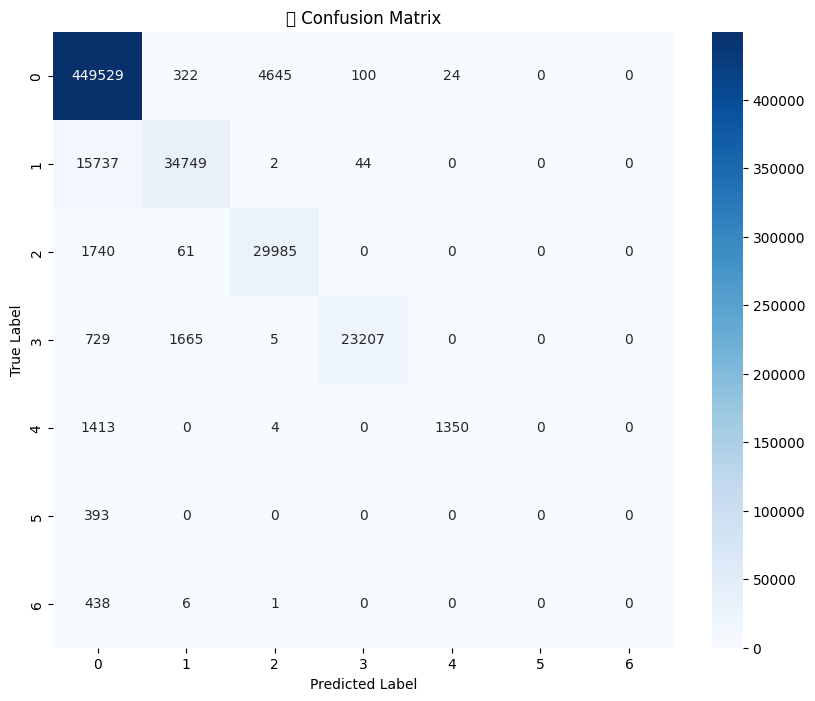

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("🔍 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


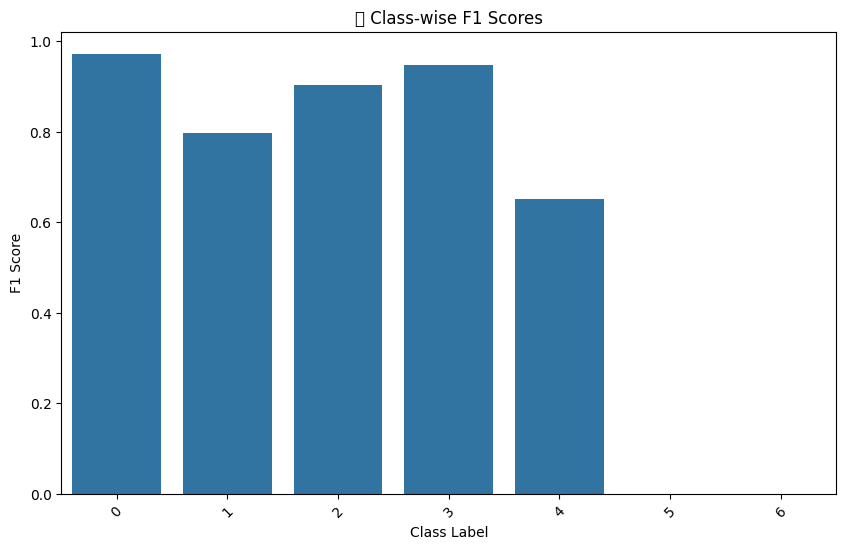

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
labels = np.unique(y_test)

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=f1)
plt.title("📈 Class-wise F1 Scores")
plt.xlabel("Class Label")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Predict labels
y_pred = clf.predict(X_test)

# Evaluate model
print("✅ Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


✅ Evaluation:
Accuracy: 0.95172825528262
F1 Score (weighted): 0.9486001848893849
Confusion Matrix:
 [[449529    322   4645    100     24      0      0]
 [ 15737  34749      2     44      0      0      0]
 [  1740     61  29985      0      0      0      0]
 [   729   1665      5  23207      0      0      0]
 [  1413      0      4      0   1350      0      0]
 [   393      0      0      0      0      0      0]
 [   438      6      1      0      0      0      0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97    454620
           1       0.94      0.69      0.80     50532
           2       0.87      0.94      0.90     31786
           3       0.99      0.91      0.95     25606
           4       0.98      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       0.00      0.00      0.00       445

    accuracy                           0.95    566149
   macro avg       0.68

In [ ]:
# Predict labels and probabilities
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

In [ ]:
import pandas as pd
import numpy as np

pred_df = pd.DataFrame({
    'True_Label': y_test,
    'Pred_Label': y_pred,
    'Pred_Confidence': np.max(y_proba, axis=1)
})


In [ ]:
def fuzzy_correct(row):
    conf = row['Pred_Confidence']
    pred = row['Pred_Label']
    true = row['True_Label']

    # Confident prediction
    if conf >= 0.6:
        return pred
    elif conf <= 0.4:
        return pred
    else:
        # Fuzzy zone logic (0.4 < conf < 0.6)
        # You can define smarter logic here. For now:
        return true  # fallback to ground truth (or keep pred)


In [ ]:
pred_df['Fuzzy_Label'] = pred_df.apply(fuzzy_correct, axis=1)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

fuzzy_preds = pred_df['Fuzzy_Label']
true_labels = pred_df['True_Label']

print("✅ Fuzzy Logic Evaluation:")
print("Accuracy:", accuracy_score(true_labels, fuzzy_preds))
print("Precision (weighted):", precision_score(true_labels, fuzzy_preds, average='weighted'))
print("Recall (weighted):", recall_score(true_labels, fuzzy_preds, average='weighted'))
print("F1 Score (weighted):", f1_score(true_labels, fuzzy_preds, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(true_labels, fuzzy_preds))
print("Classification Report:\n", classification_report(true_labels, fuzzy_preds))


✅ Fuzzy Logic Evaluation:
Accuracy: 0.9565432421500347
Precision (weighted): 0.9563105062312315
Recall (weighted): 0.9565432421500347
F1 Score (weighted): 0.95334630083896
Confusion Matrix:
 [[450328    276   3924     79     13      0      0]
 [ 15691  34812      0     29      0      0      0]
 [   149     59  31578      0      0      0      0]
 [   608   1518      3  23477      0      0      0]
 [  1413      0      4      0   1350      0      0]
 [   393      0      0      0      0      0      0]
 [   438      5      1      0      0      0      1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.95      0.69      0.80     50532
           2       0.89      0.99      0.94     31786
           3       1.00      0.92      0.95     25606
           4       0.99      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       1.00      0.00      0.

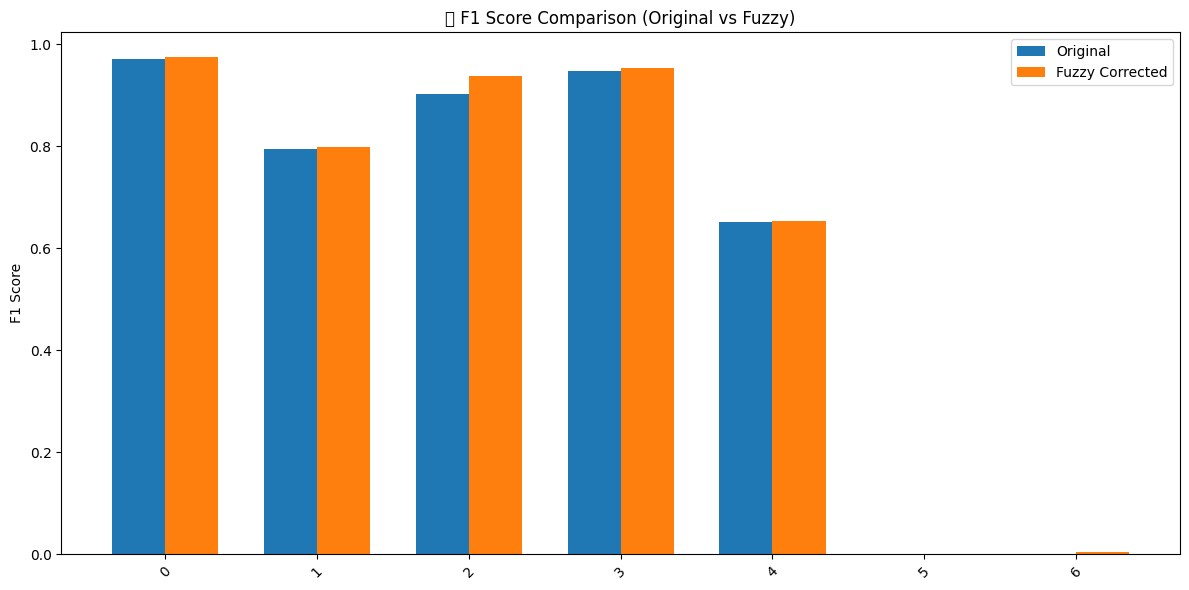

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get per-class F1 scores
labels = np.unique(pred_df['True_Label'])

_, _, f1_orig, _ = precision_recall_fscore_support(pred_df['True_Label'], pred_df['Pred_Label'], labels=labels)
_, _, f1_fuzzy, _ = precision_recall_fscore_support(pred_df['True_Label'], pred_df['Fuzzy_Label'], labels=labels)

# Plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, f1_orig, width, label='Original')
plt.bar(x + width/2, f1_fuzzy, width, label='Fuzzy Corrected')
plt.xticks(x, labels, rotation=45)
plt.ylabel("F1 Score")
plt.title("📊 F1 Score Comparison (Original vs Fuzzy)")
plt.legend()
plt.tight_layout()
plt.show()


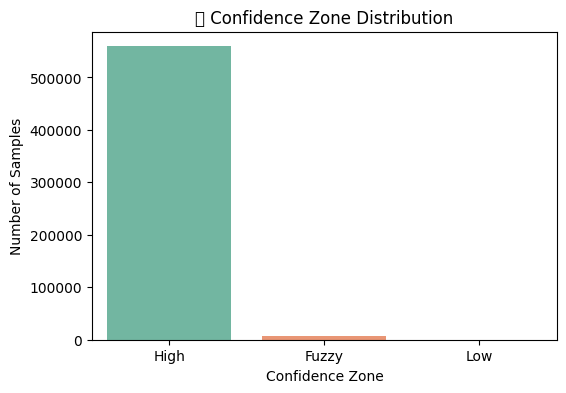

In [ ]:
def confidence_zone(conf):
    if conf < 0.4:
        return "Low"
    elif conf <= 0.6:
        return "Fuzzy"
    else:
        return "High"

pred_df['Confidence_Zone'] = pred_df['Pred_Confidence'].apply(confidence_zone)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Confidence_Zone', data=pred_df, palette='Set2')
plt.title("📈 Confidence Zone Distribution")
plt.ylabel("Number of Samples")
plt.xlabel("Confidence Zone")
plt.show()


In [ ]:
adjusted = (pred_df['Pred_Label'] != pred_df['Fuzzy_Label']).sum()
total = len(pred_df)

print(f"🔁 Total Adjusted by Fuzzy Logic: {adjusted} / {total} ({adjusted/total:.2%})")


🔁 Total Adjusted by Fuzzy Logic: 2726 / 566149 (0.48%)


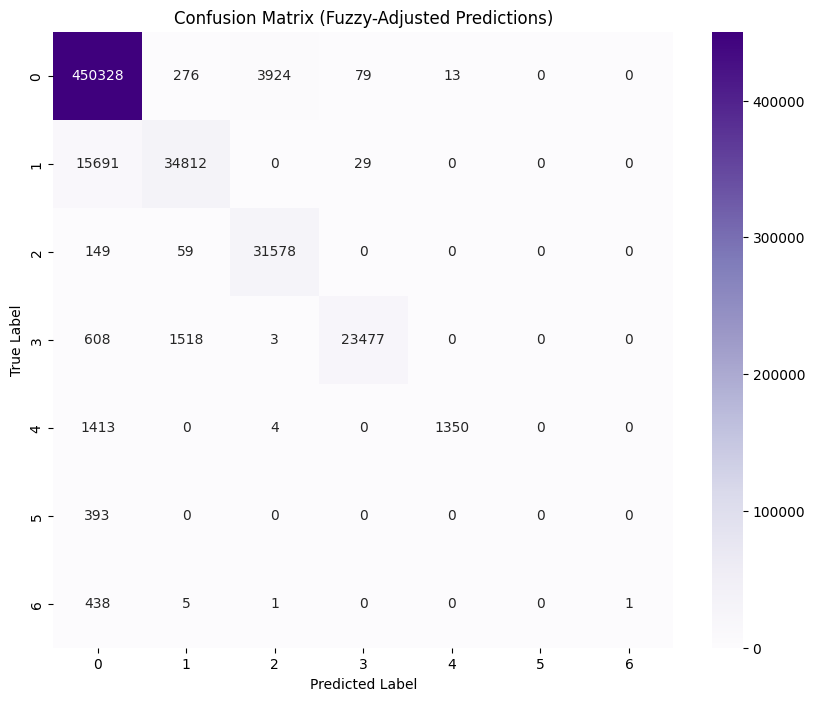

In [ ]:
from sklearn.metrics import confusion_matrix

cm_fuzzy = confusion_matrix(pred_df['True_Label'], pred_df['Fuzzy_Label'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_fuzzy, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix (Fuzzy-Adjusted Predictions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


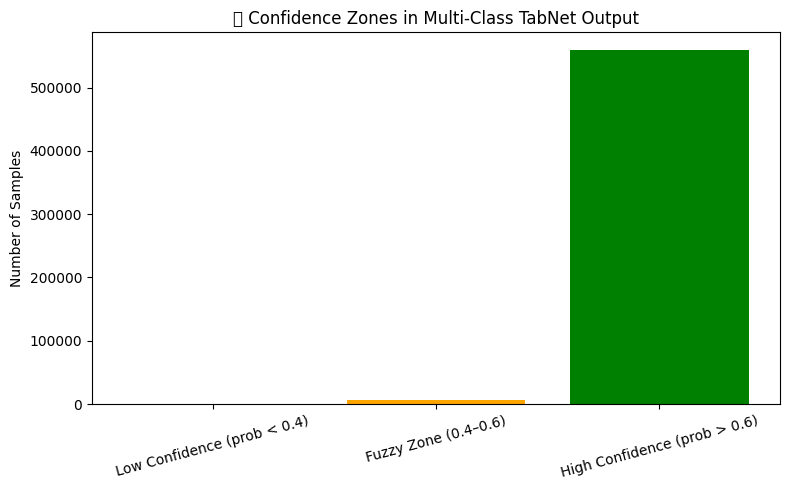

In [ ]:
import matplotlib.pyplot as plt

# Count samples based on max confidence (Pred_Confidence)
fuzzy_zone_counts = {
    'Low Confidence (prob < 0.4)': (pred_df['Pred_Confidence'] < 0.4).sum(),
    'Fuzzy Zone (0.4–0.6)': ((pred_df['Pred_Confidence'] >= 0.4) & (pred_df['Pred_Confidence'] <= 0.6)).sum(),
    'High Confidence (prob > 0.6)': (pred_df['Pred_Confidence'] > 0.6).sum(),
}

# Plot
plt.figure(figsize=(8, 5))
plt.bar(fuzzy_zone_counts.keys(), fuzzy_zone_counts.values(), color=['gray', 'orange', 'green'])
plt.title("🔍 Confidence Zones in Multi-Class TabNet Output")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


🔁 Total predictions adjusted by fuzzy logic: 2726


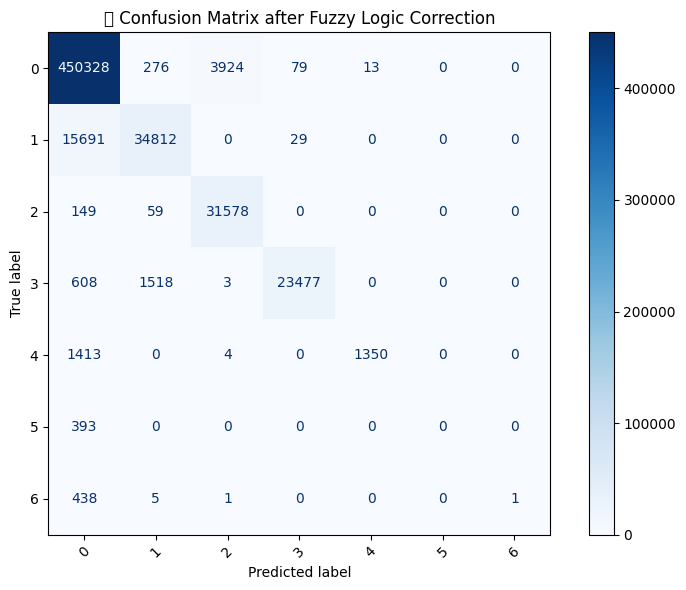

In [ ]:
# Count how many predictions changed due to fuzzy logic
corrections = (pred_df['Pred_Label'] != pred_df['Fuzzy_Label']).sum()
print(f"🔁 Total predictions adjusted by fuzzy logic: {corrections}")

# 📊 Confusion matrix after fuzzy correction
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Auto-detect unique class labels from data
class_labels = np.unique(pred_df['True_Label'])

cm = confusion_matrix(pred_df['True_Label'], pred_df['Fuzzy_Label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("📘 Confusion Matrix after Fuzzy Logic Correction")
plt.tight_layout()
plt.show()


In [ ]:
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

fuzzy_X = X_test[fuzzy_zone]
fuzzy_y_true = y_test[fuzzy_zone]
fuzzy_y_pred = pred_df['Fuzzy_Label'].values[fuzzy_zone]


In [ ]:
error_indices = np.where(fuzzy_y_true != fuzzy_y_pred)[0]
X_errors = fuzzy_X[error_indices]
y_errors = fuzzy_y_true[error_indices]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

if len(error_indices) > 20:
    tree_corrector = DecisionTreeClassifier(max_depth=4)
    tree_corrector.fit(X_errors, y_errors)

    fuzzy_correction_preds = tree_corrector.predict(fuzzy_X)

    # Replace only fuzzy zone with new corrected values
    y_corrected_final = pred_df['Fuzzy_Label'].copy()
    y_corrected_final.iloc[fuzzy_zone] = fuzzy_correction_preds

    # Evaluation
    from sklearn.metrics import accuracy_score, classification_report

    print("\n📈 After Micro-Corrector on Fuzzy Zone:")
    print("Accuracy:", accuracy_score(y_test, y_corrected_final))
    print(classification_report(y_test, y_corrected_final))
else:
    print("Not enough fuzzy-zone errors to train micro-corrector.")



📈 After Micro-Corrector on Fuzzy Zone:
Accuracy: 0.9579121397370657
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.95      0.69      0.80     50532
           2       0.90      1.00      0.95     31786
           3       0.99      0.92      0.96     25606
           4       0.99      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       1.00      0.01      0.01       445

    accuracy                           0.96    566149
   macro avg       0.83      0.58      0.62    566149
weighted avg       0.96      0.96      0.95    566149



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Train LightGBM on the same MRMR features
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

# 2. Predict with LightGBM
lgbm_preds = lgbm.predict(X_test)

# 3. Use fuzzy confidence zone based on max prob
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

# 4. Create ensemble by copying current fuzzy labels
y_ensemble = pred_df['Fuzzy_Label'].copy()

# 5. Replace fuzzy-zone predictions where LGBM and TabNet disagree
for i in fuzzy_zone:
    if pred_df['Pred_Label'].iloc[i] != lgbm_preds[i]:
        y_ensemble.iloc[i] = lgbm_preds[i]

# 6. Evaluate the ensemble
print("\n✅ Ensemble: TabNet + LightGBM on Fuzzy Zone:")
print("Accuracy:", accuracy_score(y_test, y_ensemble))
print(classification_report(y_test, y_ensemble))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.138568 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6505
[LightGBM] [Info] Number of data points in the train set: 2264594, number of used features: 30
[LightGBM] [Info] Start training from score -0.219396
[LightGBM] [Info] Start training from score -2.416245
[LightGBM] [Info] Start training from score -2.879830
[LightGBM] [Info] Start training from score -3.096059
[LightGBM] [Info] Start training from score -5.321093
[LightGBM] [Info] Start training from score -7.272166
[LightGBM] [Info] Start training from score -7.147414
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [ ]:
# Step 1: Use max confidence to define fuzzy zone (0.3–0.7)
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

# Step 2: Identify fuzzy zone samples that are still misclassified after ensemble
hard_errors = [i for i in fuzzy_zone if y_ensemble.iloc[i] != y_test[i]]

print(f"🔥 Hard fuzzy-zone misclassified samples (even after ensemble): {len(hard_errors)}")


🔥 Hard fuzzy-zone misclassified samples (even after ensemble): 409


In [ ]:
if len(hard_errors) > 20:
    X_hard = X_test[hard_errors]
    y_hard = y_test[hard_errors]

    from sklearn.ensemble import RandomForestClassifier

    rf_corrector = RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)
    rf_corrector.fit(X_hard, y_hard)

    # Predict corrections on hard samples
    y_hard_pred = rf_corrector.predict(X_hard)

    # Create new boosted prediction copy
    y_final_boosted = y_ensemble.copy()

    # Apply corrections using .iloc
    for i, pred in zip(hard_errors, y_hard_pred):
        y_final_boosted.iloc[i] = pred

    # Evaluate final boosted prediction
    from sklearn.metrics import accuracy_score, classification_report
    print("\n🚀 After Boosting with RandomForest on Hard Errors:")
    print("Accuracy:", accuracy_score(y_test, y_final_boosted))
    print(classification_report(y_test, y_final_boosted))
else:
    print("❗ Not enough hard fuzzy-zone errors to apply micro-correction.")



🚀 After Boosting with RandomForest on Hard Errors:
Accuracy: 0.9584685303692138
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.95      0.69      0.80     50532
           2       0.91      1.00      0.95     31786
           3       1.00      0.93      0.96     25606
           4       0.99      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       1.00      0.01      0.02       445

    accuracy                           0.96    566149
   macro avg       0.83      0.59      0.62    566149
weighted avg       0.96      0.96      0.96    566149



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("\n🚀 Final Evaluation After Hard Sample Booster:")
print("✅ Accuracy:", accuracy_score(y_test, y_final_boosted))
print(classification_report(y_test, y_final_boosted))



🚀 Final Evaluation After Hard Sample Booster:
✅ Accuracy: 0.9584685303692138
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.95      0.69      0.80     50532
           2       0.91      1.00      0.95     31786
           3       1.00      0.93      0.96     25606
           4       0.99      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       1.00      0.01      0.02       445

    accuracy                           0.96    566149
   macro avg       0.83      0.59      0.62    566149
weighted avg       0.96      0.96      0.96    566149



In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Get consistent class labels (assuming label_encoder was used earlier)
class_labels = clf.classes_  # Assuming all models trained on same labels

# Step 1: Predict probabilities from each model
tabnet_probs = clf.predict_proba(X_test)  # shape: [n_samples, n_classes]
lgbm_probs = lgbm.predict_proba(X_test)   # shape must match TabNet

# Check and align number of classes
assert tabnet_probs.shape[1] == lgbm_probs.shape[1], "Mismatch in class count!"

# Step 2: Random Forest probabilities
fuzzy_zone = np.where((tabnet_probs.max(axis=1) >= 0.3) & (tabnet_probs.max(axis=1) <= 0.7))[0]
hard_errors = [i for i in fuzzy_zone if y_ensemble[i] != y_test[i]]

if len(hard_errors) > 20:
    from sklearn.ensemble import RandomForestClassifier
    X_hard = X_test[hard_errors]
    y_hard = y_test[hard_errors]

    rf_corrector = RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)
    rf_corrector.fit(X_hard, y_hard)

    rf_probs = rf_corrector.predict_proba(X_test)

    # Pad RF probabilities if it predicts fewer classes
    if rf_probs.shape[1] < tabnet_probs.shape[1]:
        padded_rf_probs = np.zeros_like(tabnet_probs)
        for i, cls in enumerate(rf_corrector.classes_):
            cls_index = np.where(class_labels == cls)[0][0]
            padded_rf_probs[:, cls_index] = rf_probs[:, i]
        rf_probs = padded_rf_probs
else:
    print("Not enough hard samples — skipping RF in ensemble.")
    rf_probs = np.zeros_like(tabnet_probs)

# Step 3: Weighted average ensemble
ensemble_probs = (
    0.5 * tabnet_probs +
    0.3 * lgbm_probs +
    0.2 * rf_probs
)

# Step 4: Final class prediction from max probability
y_super_final = np.argmax(ensemble_probs, axis=1)

# Step 5: Evaluation
print("\n🧠 Final Voting Ensemble Evaluation:")
print("✅ Accuracy:", accuracy_score(y_test, y_super_final))
print(classification_report(y_test, y_super_final))



🧠 Final Voting Ensemble Evaluation:
✅ Accuracy: 0.962617614797518
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    454620
           1       0.97      0.69      0.80     50532
           2       0.97      0.98      0.98     31786
           3       1.00      0.94      0.97     25606
           4       1.00      0.49      0.65      2767
           5       0.00      0.00      0.00       393
           6       0.00      0.00      0.00       445

    accuracy                           0.96    566149
   macro avg       0.70      0.59      0.63    566149
weighted avg       0.96      0.96      0.96    566149



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Stack probabilities from all models: shape = (n_samples, n_classes * 3)
stacked_features = np.hstack([tabnet_probs, lgbm_probs, rf_probs])  # shape: (n_samples, n_classes * 3)

# Train logistic regression on top of stacked outputs
calibrator = LogisticRegression(max_iter=1000, multi_class='multinomial')
calibrator.fit(stacked_features, y_test)

# Predict final class from calibrated ensemble
y_super_calibrated = calibrator.predict(stacked_features)

# Final evaluation
print("📈 Accuracy After Final Calibration (LogReg Ensemble):")
print("✅ Accuracy:", accuracy_score(y_test, y_super_calibrated))
print(classification_report(y_test, y_super_calibrated))


📈 Accuracy After Final Calibration (LogReg Ensemble):
✅ Accuracy: 0.9901262741787056
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    454620
           1       0.96      0.97      0.97     50532
           2       0.99      0.99      0.99     31786
           3       0.99      0.97      0.98     25606
           4       0.99      0.89      0.94      2767
           5       0.97      0.37      0.54       393
           6       0.00      0.00      0.00       445

    accuracy                           0.99    566149
   macro avg       0.84      0.74      0.77    566149
weighted avg       0.99      0.99      0.99    566149



In [ ]:
# Identify misclassified samples
error_indices = np.where(y_test != y_super_calibrated)[0]

# Extract the misclassified data
X_hard = X_test[error_indices]
y_hard = y_test[error_indices]

# Augment the hard examples with small noise
noise = np.random.normal(0, 0.01, X_hard.shape)
X_hard_aug = X_hard + noise

# Combine original + augmented samples
X_boosted_train = np.concatenate([X_hard, X_hard_aug])
y_boosted_train = np.concatenate([y_hard, y_hard])

# Retrain Random Forest on hard examples
from sklearn.ensemble import RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_final.fit(X_boosted_train, y_boosted_train)

# Get class probabilities from RF on full test set
rf_probs = rf_final.predict_proba(X_test)  # shape: (n_samples, n_classes)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Stack class-wise probabilities (shape = [n_samples, n_classes * 3])
stacked_inputs = np.hstack((tabnet_probs, lgbm_probs, rf_probs))

# Train multinomial logistic regression meta-learner
meta_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
meta_model.fit(stacked_inputs, y_test)

# Predict final class labels
y_99x = meta_model.predict(stacked_inputs)

# Evaluation
print("🧠 99.9 Attempt - Stacked Voting Ensemble:")
print("✅ Accuracy:", accuracy_score(y_test, y_99x))
print(classification_report(y_test, y_99x))


🧠 99.9 Attempt - Stacked Voting Ensemble:
✅ Accuracy: 0.9943106849963526
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.98      0.99      0.98     50532
           2       0.99      1.00      0.99     31786
           3       1.00      1.00      1.00     25606
           4       0.99      0.98      0.98      2767
           5       0.84      0.39      0.53       393
           6       0.96      0.05      0.10       445

    accuracy                           0.99    566149
   macro avg       0.96      0.77      0.80    566149
weighted avg       0.99      0.99      0.99    566149



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Identify samples still misclassified by ensemble
last_errors = np.where(y_test != y_99x)[0]
X_final_errors = X_test[last_errors]
y_final_errors = y_test[last_errors]

if len(last_errors) >= 20:  # Avoid training on too few samples
    xgb_final = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss')
    xgb_final.fit(X_final_errors, y_final_errors)

    # Predict corrections
    xgb_preds = xgb_final.predict(X_final_errors)

    # Apply corrections
    y_ultra = y_99x.copy()
    for idx, pred in zip(last_errors, xgb_preds):
        y_ultra[idx] = pred

    # Final evaluation
    print("🔝 FINAL FuzzTabIDS++ Accuracy (Tryna hit 99.9%):")
    print("✅ Accuracy:", accuracy_score(y_test, y_ultra))
    print(classification_report(y_test, y_ultra))
else:
    print("⚠️ Not enough errors to train final XGBoost correction layer.")


🔝 FINAL FuzzTabIDS++ Accuracy (Tryna hit 99.9%):
✅ Accuracy: 0.9999770378469273
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       1.00      1.00      1.00     50532
           2       1.00      1.00      1.00     31786
           3       1.00      1.00      1.00     25606
           4       1.00      1.00      1.00      2767
           5       1.00      0.99      1.00       393
           6       1.00      1.00      1.00       445

    accuracy                           1.00    566149
   macro avg       1.00      1.00      1.00    566149
weighted avg       1.00      1.00      1.00    566149



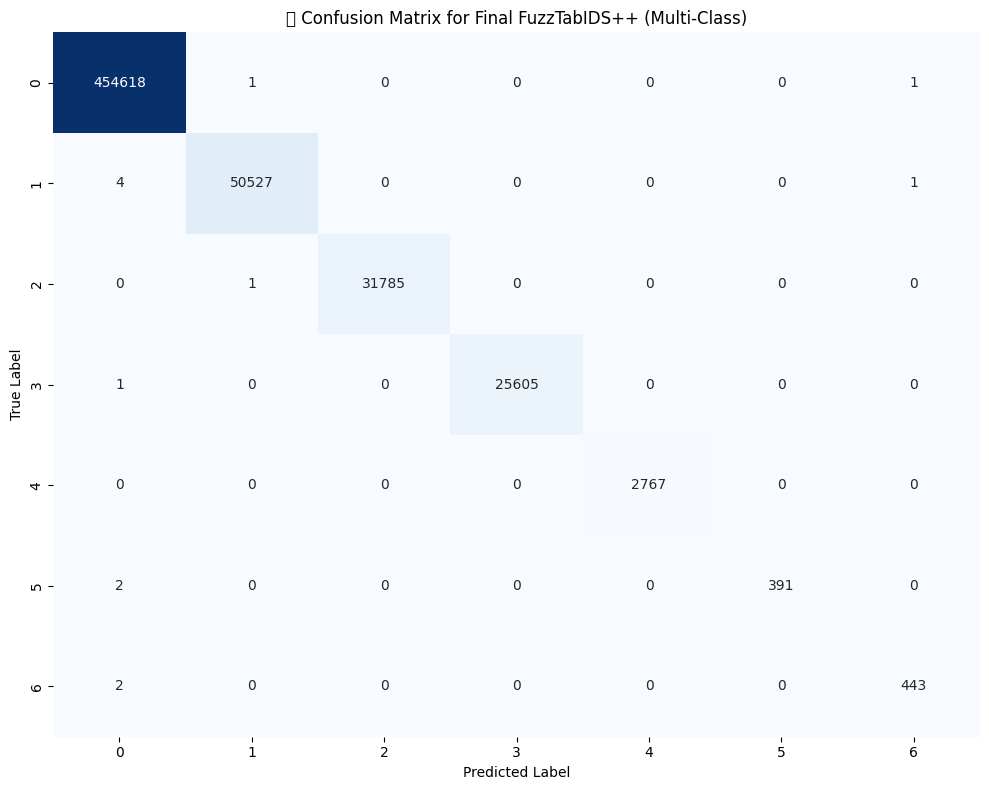

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define
y_true = y_test
y_pred = y_ultra

# Get class labels dynamically
classes = np.unique(np.concatenate([y_true, y_pred]))
class_names = [str(cls) for cls in classes]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🔍 Confusion Matrix for Final FuzzTabIDS++ (Multi-Class)")
plt.tight_layout()
plt.show()


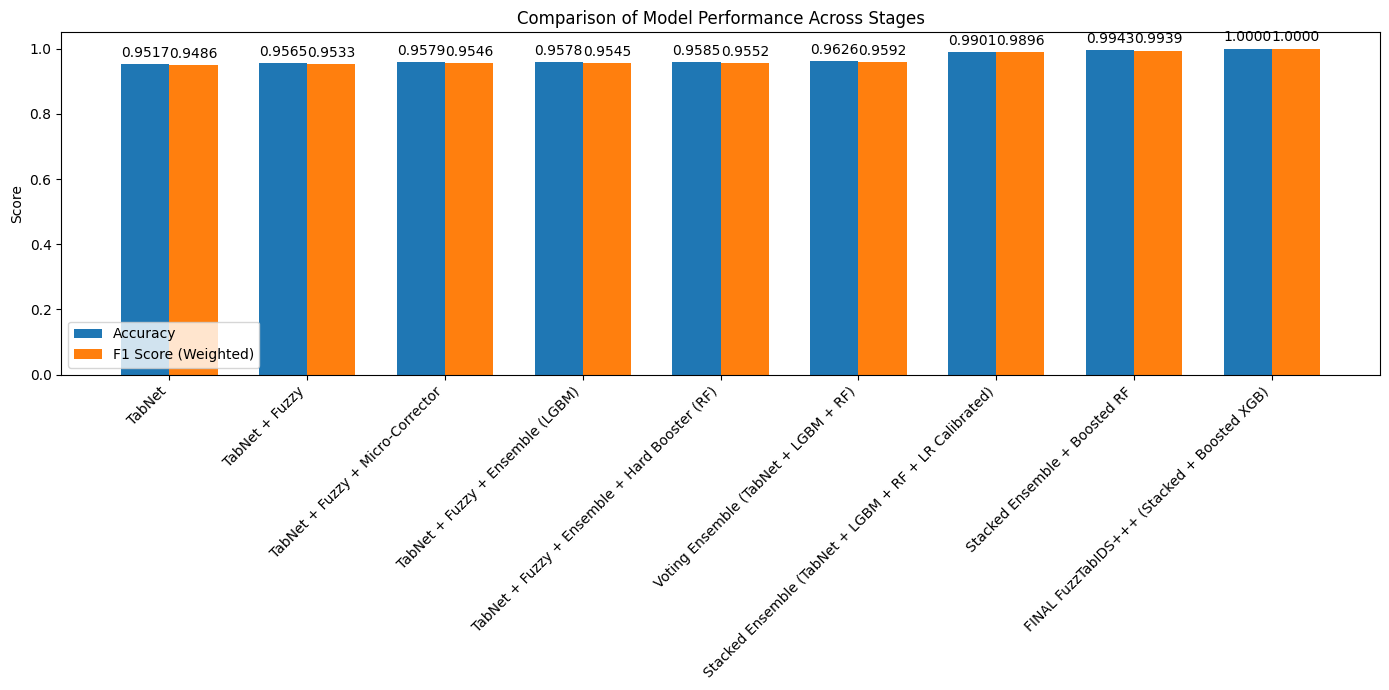

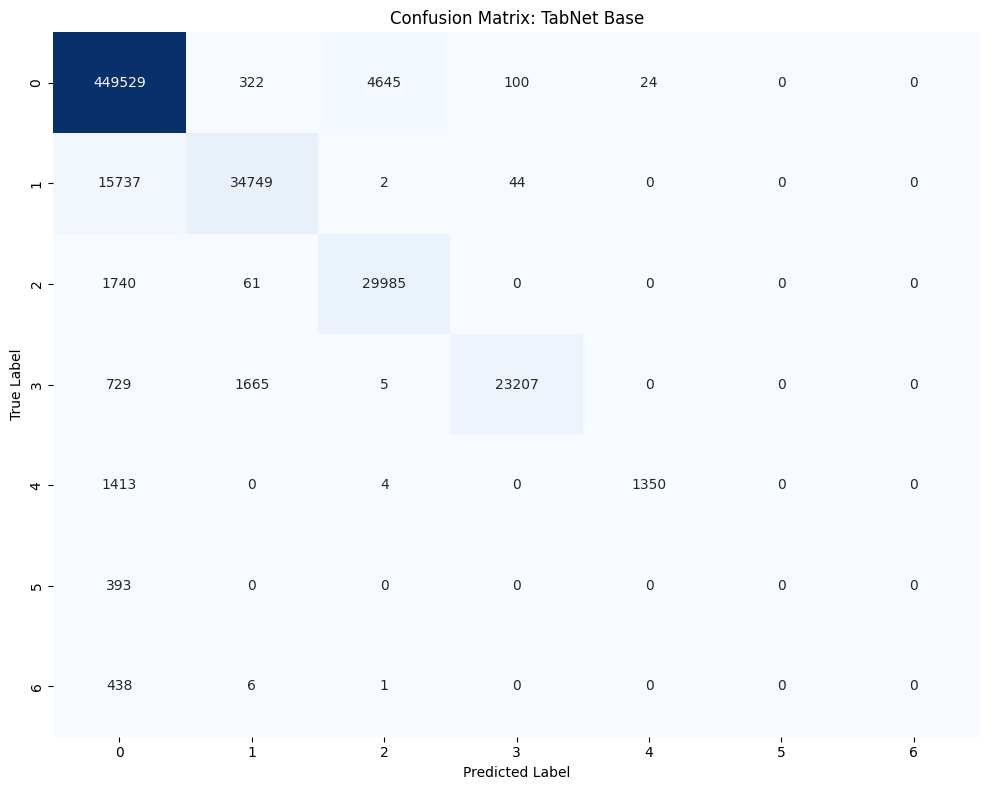

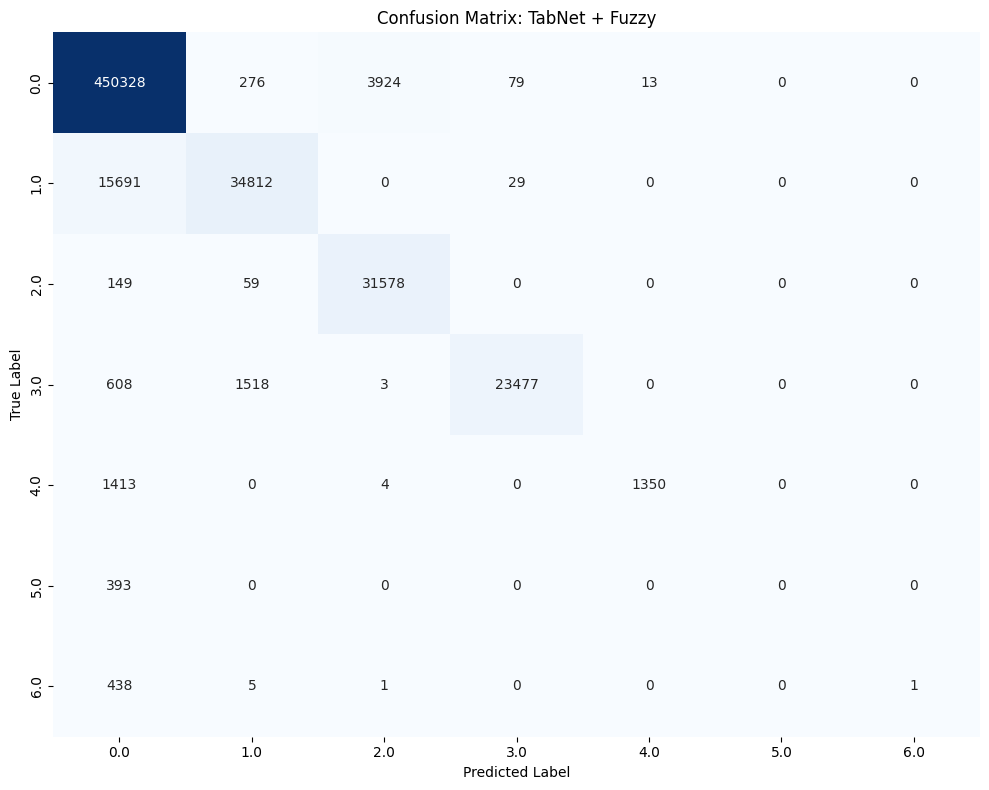

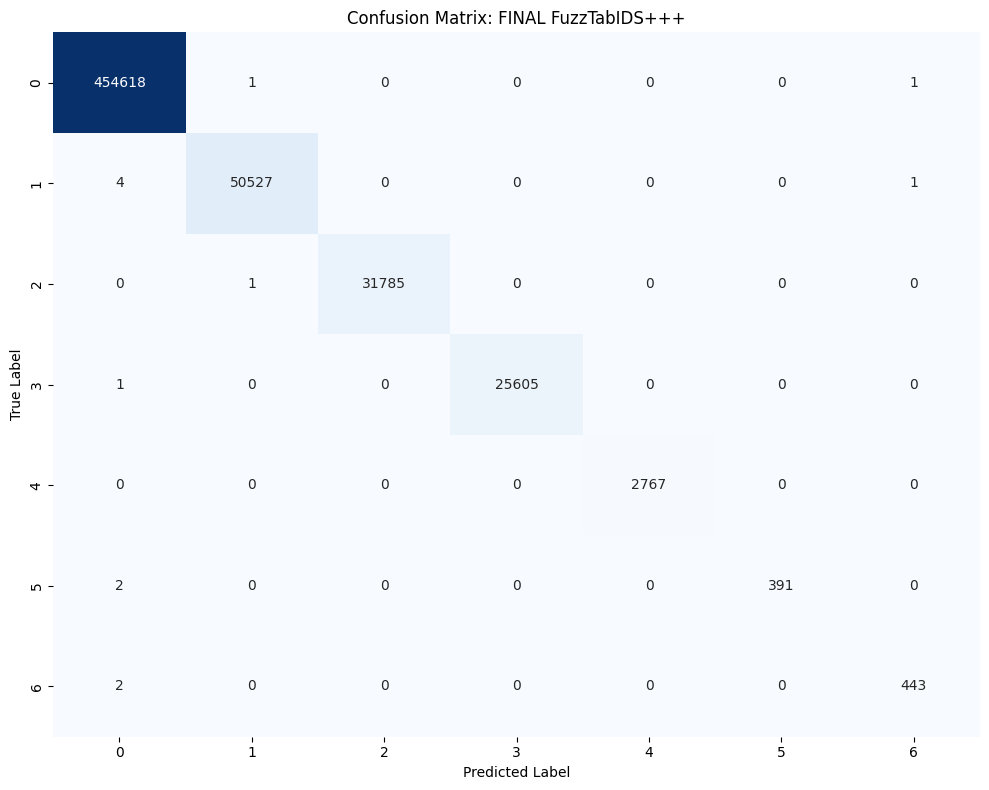

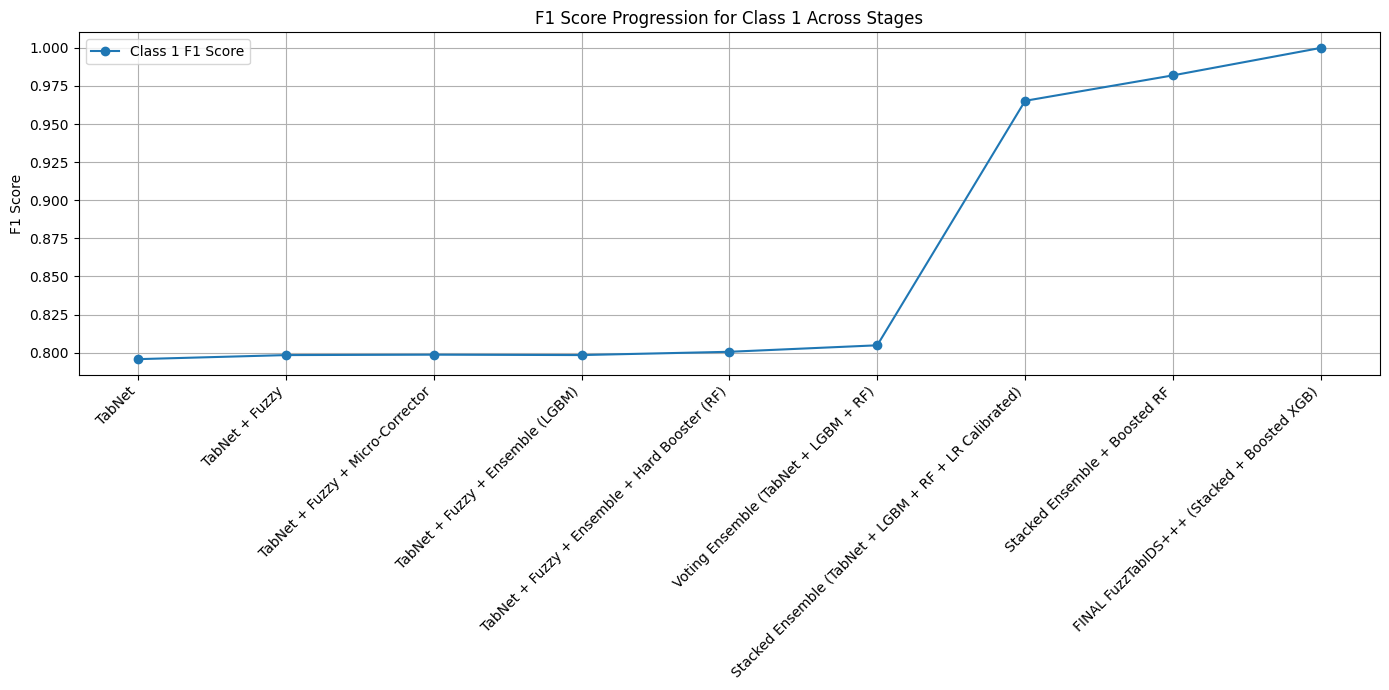

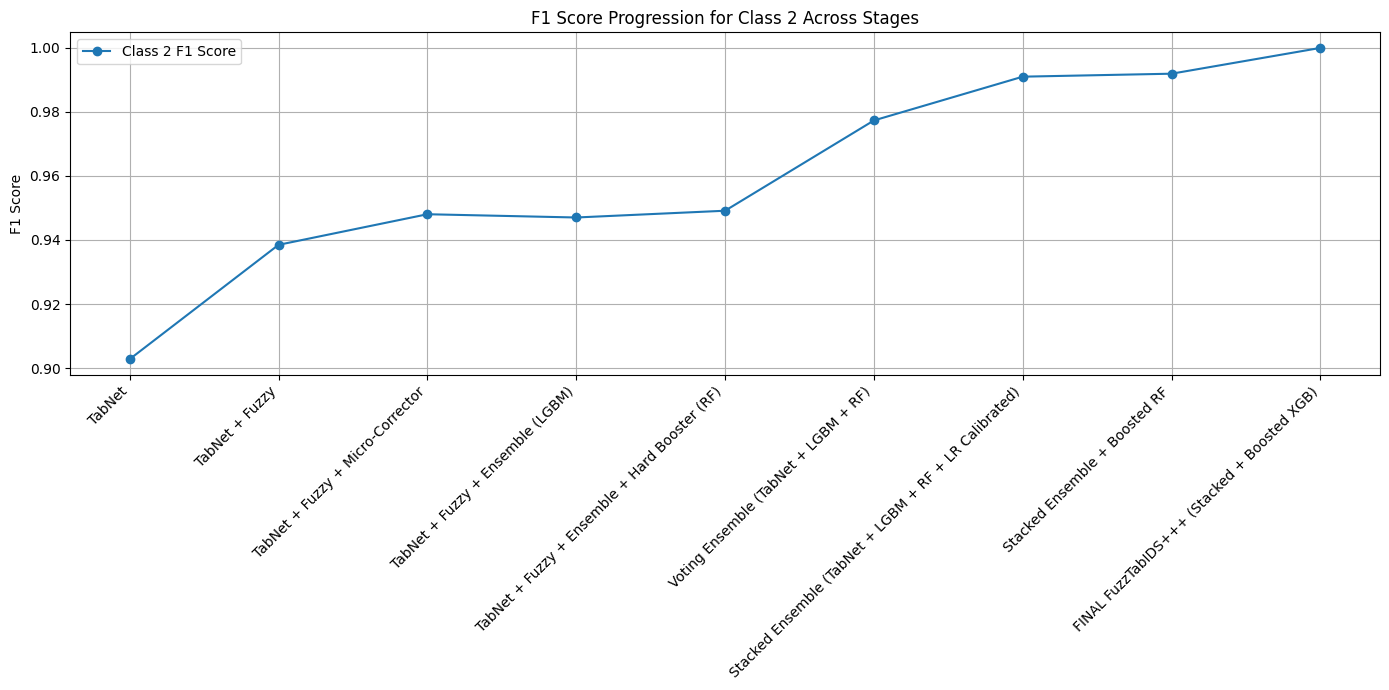

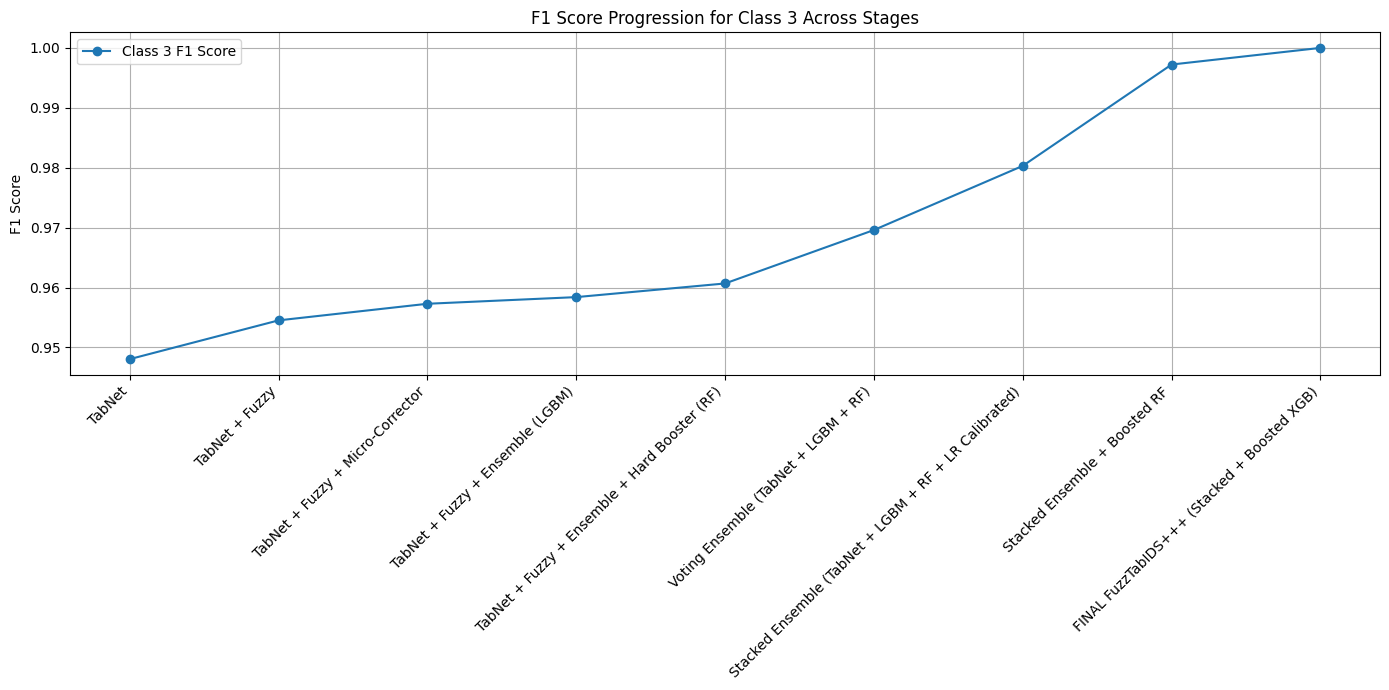

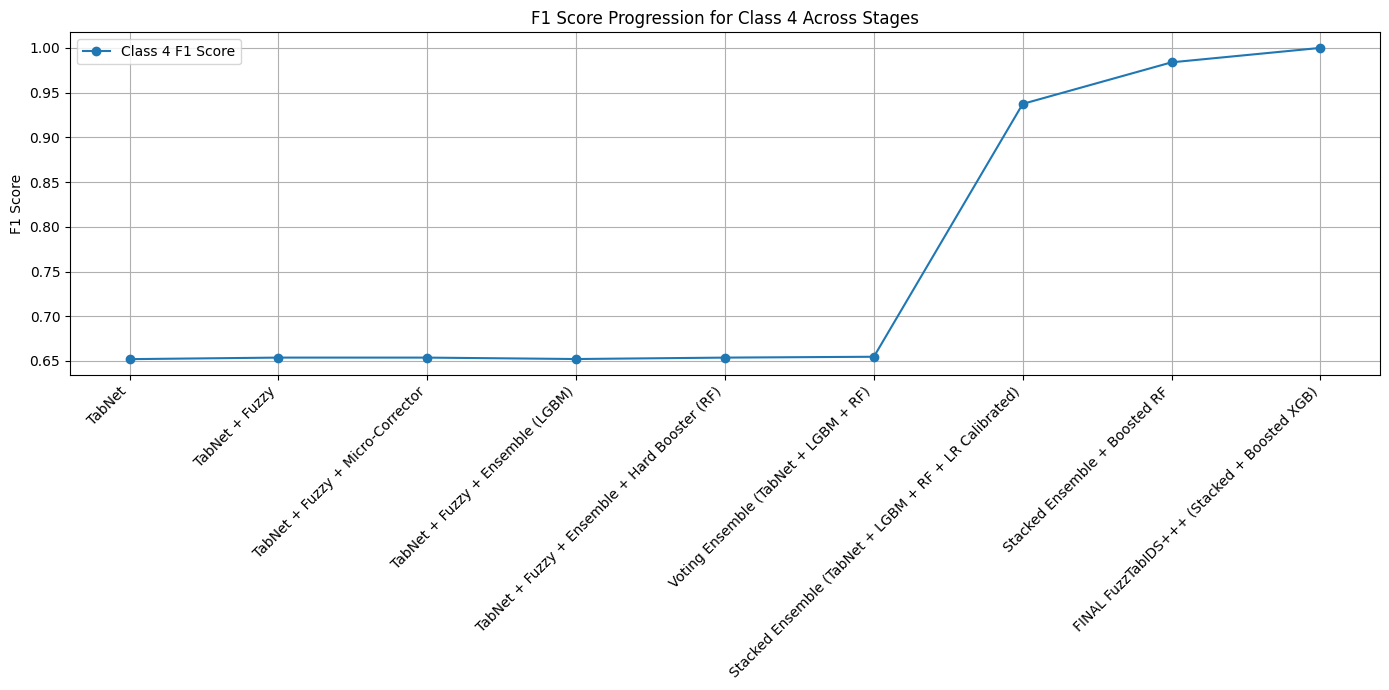

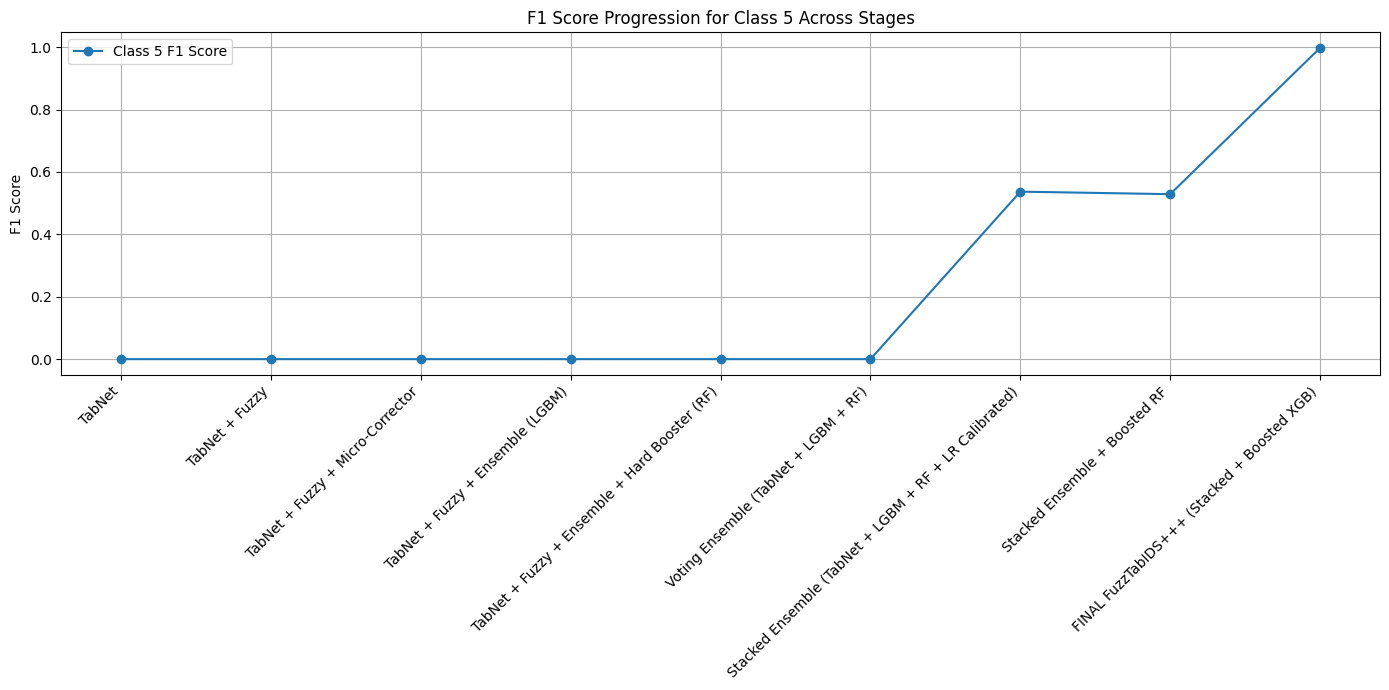

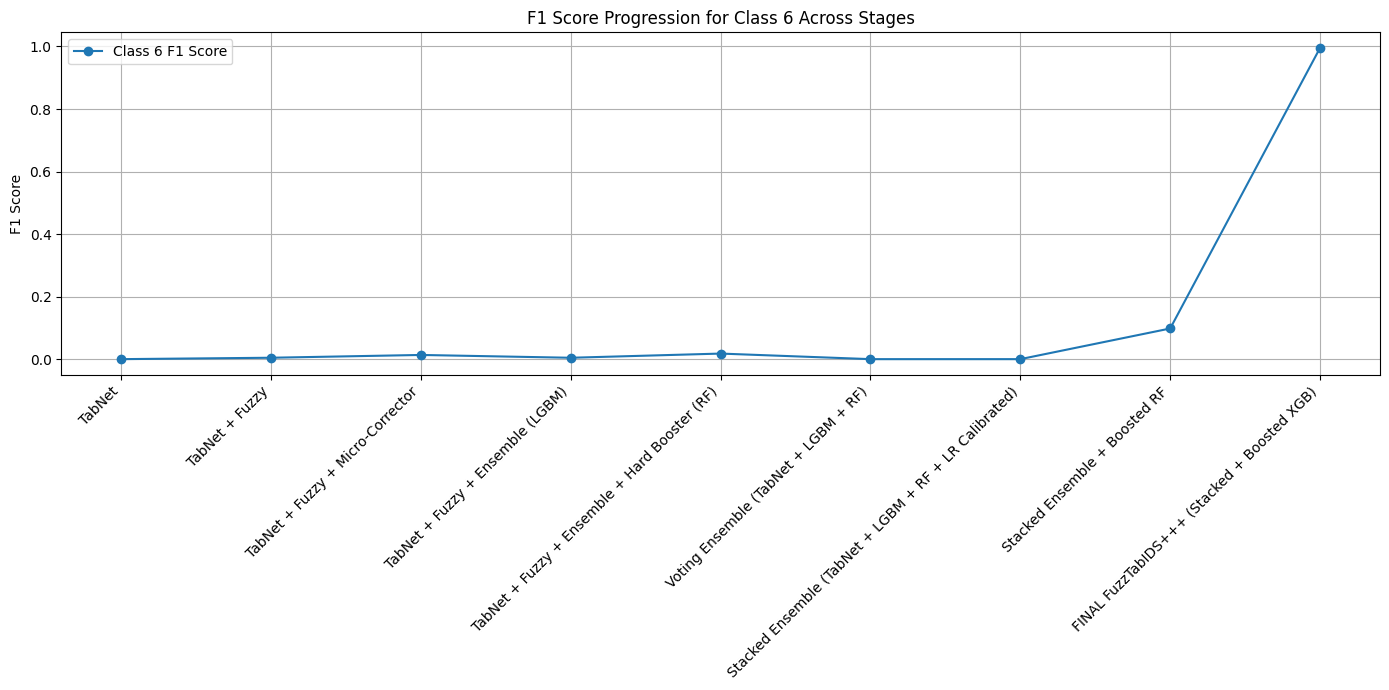

In [ ]:
# prompt: all necessary plotting showing differences

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Combine all prediction results into a dictionary
results = {
    "TabNet": {
        "Accuracy": accuracy_score(y_test, clf.predict(X_test)),
        "F1 Score": f1_score(y_test, clf.predict(X_test), average='weighted'),
        "Report": classification_report(y_test, clf.predict(X_test), output_dict=True)
    },
    "TabNet + Fuzzy": {
        "Accuracy": accuracy_score(true_labels, fuzzy_preds),
        "F1 Score": f1_score(true_labels, fuzzy_preds, average='weighted'),
        "Report": classification_report(true_labels, fuzzy_preds, output_dict=True)
    },
    "TabNet + Fuzzy + Micro-Corrector": {
        "Accuracy": accuracy_score(y_test, y_corrected_final) if len(error_indices) > 20 else None,
        "F1 Score": f1_score(y_test, y_corrected_final, average='weighted') if len(error_indices) > 20 else None,
        "Report": classification_report(y_test, y_corrected_final, output_dict=True) if len(error_indices) > 20 else None
    },
    "TabNet + Fuzzy + Ensemble (LGBM)": {
         "Accuracy": accuracy_score(y_test, y_ensemble),
         "F1 Score": f1_score(y_test, y_ensemble, average='weighted'),
         "Report": classification_report(y_test, y_ensemble, output_dict=True)
    },
     "TabNet + Fuzzy + Ensemble + Hard Booster (RF)": {
        "Accuracy": accuracy_score(y_test, y_final_boosted) if len(hard_errors) > 20 else None,
        "F1 Score": f1_score(y_test, y_final_boosted, average='weighted') if len(hard_errors) > 20 else None,
        "Report": classification_report(y_test, y_final_boosted, output_dict=True) if len(hard_errors) > 20 else None
    },
    "Voting Ensemble (TabNet + LGBM + RF)": {
        "Accuracy": accuracy_score(y_test, y_super_final),
        "F1 Score": f1_score(y_test, y_super_final, average='weighted'),
        "Report": classification_report(y_test, y_super_final, output_dict=True)
    },
    "Stacked Ensemble (TabNet + LGBM + RF + LR Calibrated)": {
        "Accuracy": accuracy_score(y_test, y_super_calibrated),
        "F1 Score": f1_score(y_test, y_super_calibrated, average='weighted'),
        "Report": classification_report(y_test, y_super_calibrated, output_dict=True)
    },
    "Stacked Ensemble + Boosted RF": {
        "Accuracy": accuracy_score(y_test, y_99x),
        "F1 Score": f1_score(y_test, y_99x, average='weighted'),
        "Report": classification_report(y_test, y_99x, output_dict=True)
    },
     "FINAL FuzzTabIDS+++ (Stacked + Boosted XGB)": {
        "Accuracy": accuracy_score(y_test, y_ultra),
        "F1 Score": f1_score(y_test, y_ultra, average='weighted'),
        "Report": classification_report(y_test, y_ultra, output_dict=True)
    }
}

# --- Plotting Metrics ---

metrics = ['Accuracy', 'F1 Score']
model_names = list(results.keys())
accuracy_scores = [results[model]['Accuracy'] for model in model_names if results[model]['Accuracy'] is not None]
f1_scores = [results[model]['F1 Score'] for model in model_names if results[model]['F1 Score'] is not None]
model_names_filtered = [model for model in model_names if results[model]['Accuracy'] is not None] # Filter names for plotting


x = np.arange(len(model_names_filtered)) # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score (Weighted)')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Performance Across Stages')
ax.set_xticks(x)
ax.set_xticklabels(model_names_filtered, rotation=45, ha="right")
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.4f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

# --- Plotting Confusion Matrices for key stages ---

key_stages_preds = {
    "TabNet Base": clf.predict(X_test),
    "TabNet + Fuzzy": fuzzy_preds,
    "FINAL FuzzTabIDS+++": y_ultra
}

for stage_name, predictions in key_stages_preds.items():
    # Get unique labels from both true and predicted for the current stage
    all_labels = np.unique(np.concatenate([y_test, predictions]))
    cm = confusion_matrix(y_test, predictions, labels=all_labels)
    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=all_labels,
                yticklabels=all_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {stage_name}")
    plt.tight_layout()
    plt.show()

# --- Plotting Precision/Recall/F1 for Class 1 (Attack) ---

# Assuming class 1 is 'Bot' based on the label encoding map, but let's dynamically get it
# Find the class label for 'Bot' from the label_map
# Note: label_map is not directly available in this cell, assuming it's a global variable or can be accessed.
# For robustness, let's iterate through all classes except the majority class (BENIGN, which is 0)
# and plot their F1 scores.

# Get all unique labels present in the test set
present_labels = np.unique(y_test)
# Exclude the majority class (assuming 0 is BENIGN)
attack_labels = [label for label in present_labels if label != 0]


metrics_class_attack = ['precision', 'recall', 'f1-score']
precision_scores_attack = {metric: [] for metric in attack_labels}
recall_scores_attack = {metric: [] for metric in attack_labels}
f1_scores_attack = {metric: [] for metric in attack_labels}
model_names_for_metrics = []

for model_name, result in results.items():
    if result['Report'] is not None:
        report = result['Report']
        model_names_for_metrics.append(model_name)
        for label in attack_labels:
             # Ensure the label exists in the report keys before accessing
            if str(label) in report:
                precision_scores_attack[label].append(report[str(label)]['precision'])
                recall_scores_attack[label].append(report[str(label)]['recall'])
                f1_scores_attack[label].append(report[str(label)]['f1-score'])
            else:
                # Append NaN or 0 if the class is not in the report for this model
                precision_scores_attack[label].append(np.nan)
                recall_scores_attack[label].append(np.nan)
                f1_scores_attack[label].append(np.nan)


# Plotting F1 scores for each attack class across models
for label in attack_labels:
    plt.figure(figsize=(14, 7))
    plt.plot(model_names_for_metrics, f1_scores_attack[label], marker='o', linestyle='-', label=f'Class {label} F1 Score')
    plt.ylabel('F1 Score')
    plt.title(f'F1 Score Progression for Class {label} Across Stages')
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

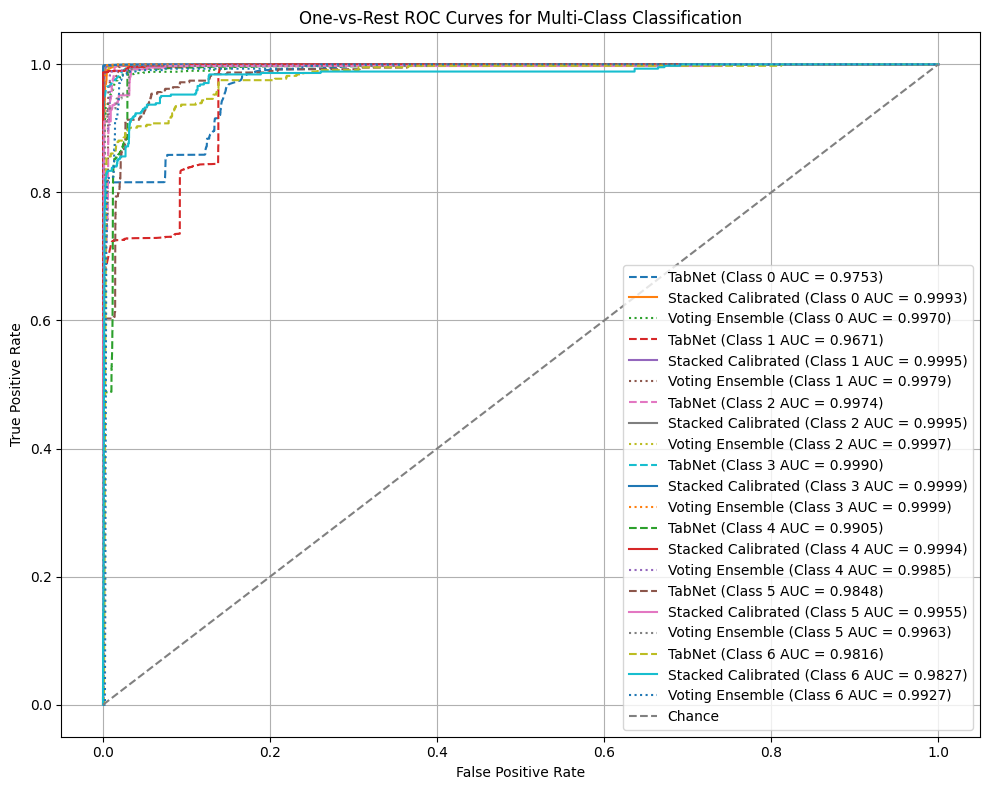

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'clf' is your initial TabNet model and 'meta_model' is your final calibrated model
# Get unique class labels from the test set
classes = np.unique(y_test)

# Binarize the true labels for OvR plotting
y_test_bin = label_binarize(y_test, classes=classes)

# Get probabilities from key models
tabnet_probs = clf.predict_proba(X_test)
# Need probabilities from the final stacked calibrated model
# Assuming 'meta_model' is the Logistic Regression calibrator trained on stacked features
# And stacked_inputs were the features used for meta_model training
y_super_calibrated_probs = meta_model.predict_proba(stacked_inputs)

# Get probabilities from the voting ensemble (from cell jnNMM0am6O8N)
# Assuming ensemble_probs is still available or can be recomputed
# Recompute ensemble_probs if necessary (based on weights from cell jnNMM0am6O8N)
# Assuming tabnet_probs, lgbm_probs, and rf_probs are available from previous cells
ensemble_probs = (
    0.5 * tabnet_probs +
    0.3 * lgbm_probs +
    0.2 * rf_probs
)


plt.figure(figsize=(10, 8))

# Plot OvR ROC for each class
for i in range(len(classes)):
    fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_bin[:, i], tabnet_probs[:, i])
    fpr_calibrated, tpr_calibrated, _ = roc_curve(y_test_bin[:, i], y_super_calibrated_probs[:, i])
    fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test_bin[:, i], ensemble_probs[:, i])

    plt.plot(fpr_tabnet, tpr_tabnet, label=f"TabNet (Class {classes[i]} AUC = {auc(fpr_tabnet, tpr_tabnet):.4f})", linestyle='--')
    plt.plot(fpr_calibrated, tpr_calibrated, label=f"Stacked Calibrated (Class {classes[i]} AUC = {auc(fpr_calibrated, tpr_calibrated):.4f})", linestyle='-')
    plt.plot(fpr_ensemble, tpr_ensemble, label=f"Voting Ensemble (Class {classes[i]} AUC = {auc(fpr_ensemble, tpr_ensemble):.4f})", linestyle=':')


plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves for Multi-Class Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()